In [13]:
#Import Pandas for data loading, cleaning, and manipulation
import pandas as pd
# Import Matplotlib for creating and customizing plots/figures
import matplotlib.pyplot as plt
# Import LabelEncoder from Scikit-learn to convert categorical labels into numeric codes
from sklearn.preprocessing import LabelEncoder
#Import Seaborn for statistical data visualization
import seaborn as sns

In [15]:
#Load the original dataset
df = pd.read_csv("secondary_data.csv", sep=';')

In [17]:
numeric_cols = ["cap-diameter", "stem-height", "stem-width"]
categorical_cols = [col for col in df.columns if col not in numeric_cols]

In [19]:
#Label Encoding for target column 'class'
label_encoder = LabelEncoder()
df['class_encoded'] = label_encoder.fit_transform(df['class'])
print(df['class_encoded'])

0        1
1        1
2        1
3        1
4        1
        ..
61064    1
61065    1
61066    1
61067    1
61068    1
Name: class_encoded, Length: 61069, dtype: int64


In [21]:
#One Hot Encoding for other categorical features
df_encoded = pd.get_dummies(df, columns=[col for col in categorical_cols if col != 'class'])
print(df_encoded)

      class  cap-diameter  stem-height  stem-width  class_encoded  \
0         p         15.26        16.95       17.09              1   
1         p         16.60        17.99       18.19              1   
2         p         14.07        17.80       17.74              1   
3         p         14.17        15.77       15.98              1   
4         p         14.64        16.53       17.20              1   
...     ...           ...          ...         ...            ...   
61064     p          1.18         3.93        6.22              1   
61065     p          1.27         3.18        5.43              1   
61066     p          1.27         3.86        6.37              1   
61067     p          1.24         3.56        5.44              1   
61068     p          1.17         3.25        5.45              1   

       cap-shape_b  cap-shape_c  cap-shape_f  cap-shape_o  cap-shape_p  ...  \
0            False        False        False        False        False  ...   
1            

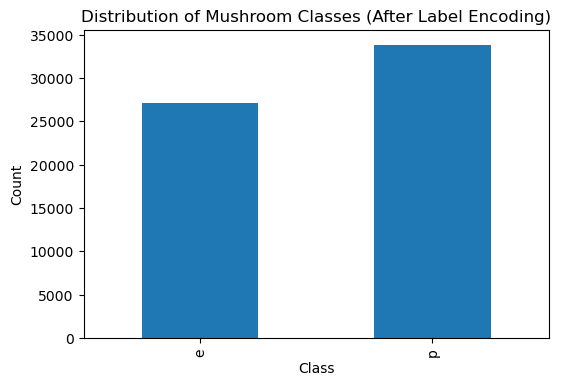

In [25]:
# Class distribution after encoding
plt.figure(figsize=(6,4))
df["class_encoded"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Mushroom Classes (After Label Encoding)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0,1], label_encoder.classes_) 
plt.show()

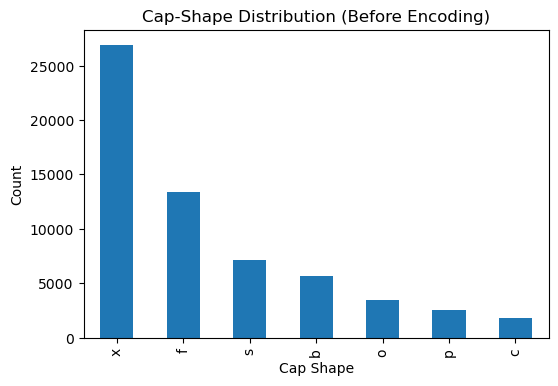

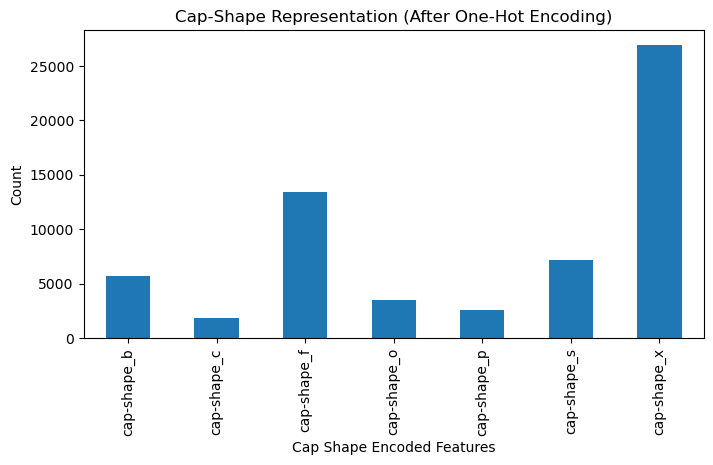

In [27]:
# Feature (cap-shape) Before vs After One-Hot Encoding
# Before encoding
plt.figure(figsize=(6,4))
df["cap-shape"].value_counts().plot(kind="bar")
plt.title("Cap-Shape Distribution (Before Encoding)")
plt.xlabel("Cap Shape")
plt.ylabel("Count")
plt.show()

# After encoding
cap_shape_cols = [col for col in df_encoded.columns if col.startswith("cap-shape_")]
plt.figure(figsize=(8,4))
df_encoded[cap_shape_cols].sum().plot(kind="bar")
plt.title("Cap-Shape Representation (After One-Hot Encoding)")
plt.xlabel("Cap Shape Encoded Features")
plt.ylabel("Count")
plt.show()